In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import cv2
import pathlib
import os
import string
from PIL import Image
from keras import backend as K
import matplotlib.pyplot as plt

2026-02-26 21:46:05.308634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 21:46:05.335679: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 21:46:06.053941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Introduction

- What does the convolutional neural network depend on in making its decision? The next project shows the way in which areas can be identified from the medical images through which a decision can be made whether there is a cancerous tumor in the medical images or not and generate a heat map that helps determine the places of most interest for the convolutional neural network. Which helped her make her decision.
- Two methodologies were used to track the location of the cancer tumor based on a convolutional neural network whose task is to classify the presence of a cancerous disease, and thus the study explains and interprets what the convolutional neural network sees and what it relies on in making the final classification decision.
- GradCAM / GradCAM++ is used to interpret what a convolutional neural network sees.

# Preparation and processing of dataset

### 1. Install the Kaggle API Client

In [2]:
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("alifrahman/chestxraydataset")

print("Path to dataset files:", path)

/home/vrathik/grad_cam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.14G/1.14G [01:10<00:00, 17.3MB/s]

Extracting files...


Path to dataset files: /home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1


### 5. Unzip the Dataset

Most Kaggle datasets are downloaded as `.zip` files. You'll need to unzip them to access the contents. You can also specify the target directory for unzipping.

In [3]:
# List the contents of the downloaded directory to inspect its structure
print(f"Contents of {path}:")
!ls -R "{path}"

# The actual data is usually nested within 'Brain Tumor Data Set/Brain Tumor Data Set'
# We will set the final datasetfolder in the next cell.

Contents of /home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1:
/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1:
chest_xray

/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1/chest_xray:
test  train

/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1/chest_xray/test:
NORMAL	PNEUMONIA

/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1/chest_xray/test/NORMAL:
IM-0001-0001.jpeg	   NORMAL2-IM-0173-0001-0001.jpeg
IM-0003-0001.jpeg	   NORMAL2-IM-0173-0001-0002.jpeg
IM-0005-0001.jpeg	   NORMAL2-IM-0195-0001.jpeg
IM-0006-0001.jpeg	   NORMAL2-IM-0196-0001.jpeg
IM-0007-0001.jpeg	   NORMAL2-IM-0198-0001.jpeg
IM-0009-0001.jpeg	   NORMAL2-IM-0199-0001.jpeg
IM-0010-0001.jpeg	   NORMAL2-IM-0201-0001.jpeg
IM-0011-0001-0001.jpeg	   NORMAL2-IM-0206-0001.jpeg
IM-0011-0001-0002.jpeg	   NORMAL2-IM-0207-0001.jpeg
IM-0011-0001.jpeg	   NORMAL2-IM-0210-0001.jpeg
IM-00

### 6. Update the `datasetfolder` variable

Now that the dataset is downloaded and unzipped, you can update the `datasetfolder` variable in your notebook to point to the correct path within Colab.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
ge = ImageDataGenerator(rescale = 1/255,
                        rotation_range=0.2,
                        width_shift_range=0.05,
                        height_shift_range=0.05,
                        fill_mode = 'constant',
                        validation_split = 0.2,
                        horizontal_flip = True,
                        vertical_flip = True,
                        zoom_range = 0.2
                        )

In [ ]:

dataflowtraining = ge.flow_from_directory(directory = "/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1/chest_xray/train",
                                 target_size = (224, 224),
                                 color_mode = 'rgb',
                                 batch_size = 32,
                                 shuffle = True,
                                 subset = 'training')
dataflowvalidation = ge.flow_from_directory(directory = "/home/vrathik/.cache/kagglehub/datasets/alifrahman/chestxraydataset/versions/1/chest_xray/test",
                                           target_size = (224, 224),
                                           color_mode = 'rgb',
                                           batch_size = 32,
                                           shuffle = True,
                                           subset = 'validation')

Found 4173 images belonging to 2 classes.
Found 124 images belonging to 2 classes.


In [7]:
pip install scipy



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
images, labels = next(dataflowvalidation)
np.min(images), np.max(images)

(0.0, 1.0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


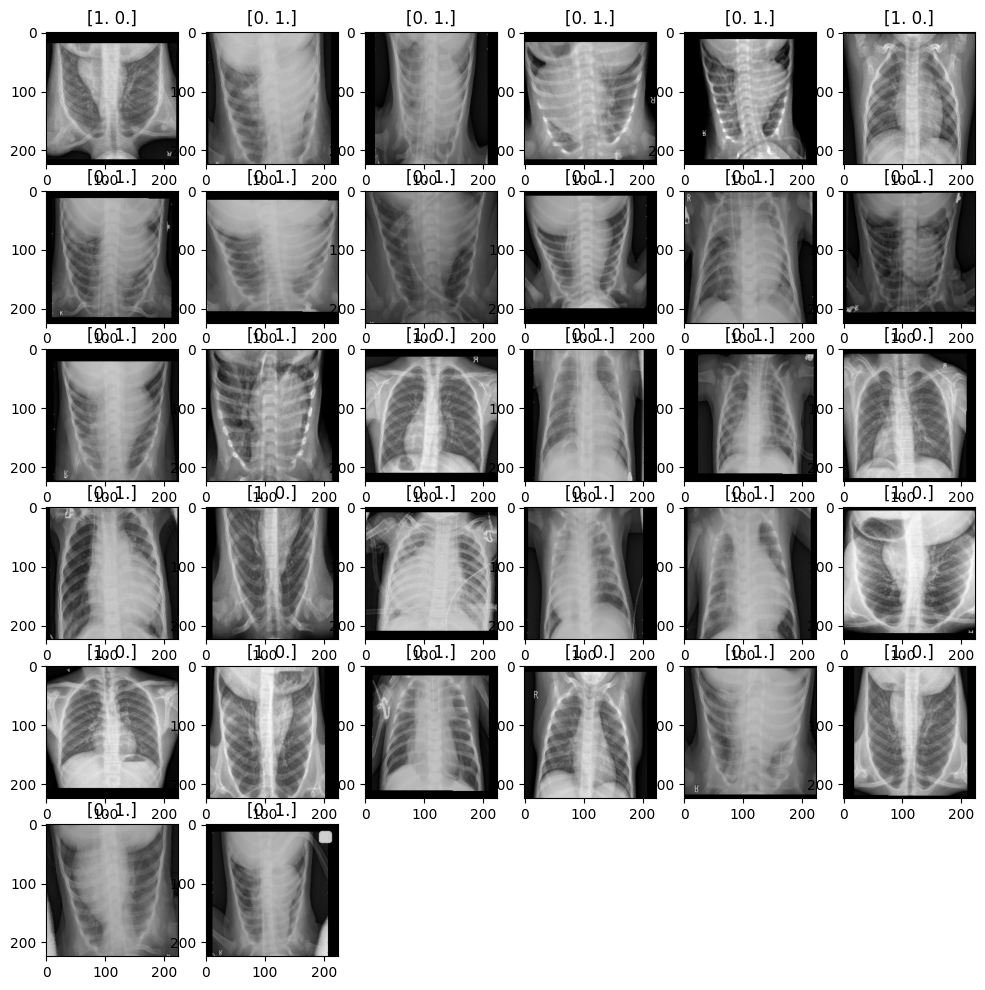

In [9]:
import matplotlib.pyplot as plt
images, labels = next(dataflowvalidation)
plt.figure(figsize = (12, 12))
for i in range(32):
    plt.subplot(6, 6, (i + 1))
    plt.imshow(images[i])
    plt.title(labels[i])
plt.legend()

# Convolutional neural network architecture proposal

We note here, that I did not freeze the first layers of the pre-trained neural network, but rather used weights to give a good or acceptable range and initialization to the weights included in the neural network, instead of starting from a random initialization of the values of the weights.

In [10]:
from keras.applications import DenseNet121
basemodel = DenseNet121(weights = 'imagenet', include_top = False,
                        input_shape = (224, 224, 3), pooling = None)
x = tf.keras.layers.Flatten()(basemodel.output)
x = tf.keras.layers.Dropout(0.7)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(16, activation = 'relu',)(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(2, activation = 'softmax')(x)
m = tf.keras.models.Model(inputs = basemodel.input, outputs = x)
m.compile(loss = 'binary_crossentropy',
          optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
         metrics = ['accuracy', tf.keras.metrics.Precision(name = 'precision'),
                   tf.keras.metrics.Recall(name = 'recall')])

2026-02-23 09:14:52.048600: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
hist = m.fit(dataflowtraining, epochs = 10, batch_size = 32, #og epoch: 60
             validation_data = dataflowvalidation,
             callbacks = [
                tf.keras.callbacks.EarlyStopping(patience = 8, monitor = 'val_loss', mode = 'min',
                                                restore_best_weights = True),
                tf.keras.callbacks.ReduceLROnPlateau(patience = 6, monitor = 'val_loss',
                                                          mode = 'min', factor = 0.1)
            ])

Epoch 1/10
119/131 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.6900 - loss: 0.6452 - precision: 0.6900 - recall: 0.6900

# Results

In [ ]:
m.evaluate(dataflowtraining)

In [ ]:
m.evaluate(dataflowvalidation)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12, 6))
metrics = ['loss', 'precision', 'recall', 'accuracy']
for i in range(4):
    plt.subplot(2, 2, (i + 1))
    plt.plot(hist.history[metrics[i]], label = metrics[i])
    plt.plot(hist.history['val_{}'.format(metrics[i])], label = 'val_{}'.format(metrics[i]))
plt.legend()

In [ ]:
m.save('./models/final_tumor_model.h5')

# Heat Map:
In this section, the focus was on the medical images in which there was a cancerous tumor, and the neural network was asked to predict that it contained a cancerous tumor or not, and at the same time to identify the areas that were relied upon in making a decision that the cancerous tumor was present within it.

In [ ]:
def readtumorImages(imagespathes):
    images = []
    for img in imagespathes:
        img = cv2.imread(str(img))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img/255
        img = cv2.resize(img, (224, 224))
        images.append(img)
    return np.array(images)

In [ ]:
images = readtumorImages(list(pathlib.Path('/kaggle/input/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor').glob('*.*'))[:1000])
labels = tf.keras.utils.to_categorical(tf.zeros(shape = (images.shape[0])), num_classes = 2)
images.shape, labels.shape

In [ ]:
indexs = np.random.choice(images.shape[0], size=images.shape[0], replace=False)
images = tf.gather(images, indexs)
labels = tf.gather(labels, indexs)
images.shape, labels.shape

In [ ]:
m = tf.keras.models.load_model('./models/final_tumor_model.h5')

# Grad-Cam

In [ ]:
def gradCam(image, true_label, layer_conv_name):
    model_grad = tf.keras.models.Model(inputs = m.input,
                              outputs = [m.get_layer(layer_conv_name).output,
                                         m.output])
    with tf.GradientTape() as tape:
        conv_output, predictions = model_grad(image)
        tape.watch(conv_output)
        loss = tf.losses.binary_crossentropy(true_label, predictions)
    grad = tape.gradient(loss, conv_output)
    # Changed K.mean to tf.reduce_mean
    grad = tf.reduce_mean(tf.abs(grad), axis = (0, 1, 2))
    conv_output = np.squeeze(conv_output.numpy())
    for i in range(conv_output.shape[-1]):
        conv_output[:, :, i] *= grad[i]
    heatmap = np.mean(conv_output, axis = -1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(heatmap * 255)
    return heatmap, np.squeeze(image)

In [ ]:
def getHeatMap(images, labels):
    heatmaps = []
    for index in range(len(images)):
        heatmap, image = gradCam(images[index: index + 1],
                                               labels[index: index + 1],
                                           'relu')
        heatmaps.append(heatmap)
    return np.array(heatmaps)

In [ ]:
# Collect 128 images (4 batches of 32)
all_images = []
all_labels = []

for _ in range(4):
    imgs, lbls = next(dataflowvalidation)
    all_images.append(imgs)
    all_labels.append(lbls)

images = np.concatenate(all_images, axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

In [ ]:
heatmaps = getHeatMap(images, labels)
heatmaps.shape

# Grad-Cam++

In [ ]:
def grad_cam_plus_plus(image, true_label, conv_layer):
    gradModel = tf.keras.models.Model(inputs = m.input, outputs = [
        m.get_layer(conv_layer).output,
        m.output
    ])
    with tf.GradientTape() as tape:
        conv_output, predict = gradModel(image)
        tape.watch(conv_output)
        score = predict[:, np.argmax(predict[0])]
    grads = tape.gradient(score, conv_output)
    score_exp = tf.reshape(tf.exp(score), (-1, 1, 1, 1))
    first = score_exp * grads
    second = score_exp * grads * grads
    third = score_exp * grads * grads * grads
    first = np.squeeze(first.numpy(), axis=0)
    second = np.squeeze(second.numpy(), axis=0)
    third = np.squeeze(third.numpy(), axis=0)
    conv_output_sq = np.squeeze(conv_output.numpy(), axis=0)
    x = np.sum(conv_output_sq, axis=(0, 1))
    alpha = second / (2 * second + third * x[np.newaxis, np.newaxis, :] + 1e-10)
    weights = np.sum(alpha * np.maximum(first, 0.0), axis=(0, 1))
    heatmap = np.zeros(conv_output_sq.shape[0:2], dtype=np.float32)
    for i in range(weights.shape[0]):
        heatmap += weights[i] * conv_output_sq[:, :, i]
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-10)
    heatmap = cv2.resize(heatmap, (224, 224))
    return heatmap

In [ ]:
def getHeatMap_plus_plus(images, labels):
    heatmaps = []
    for index in range(len(images)):
        heatmap = grad_cam_plus_plus(images[index: index + 1],
                                               labels[index: index + 1],
                                           'relu')
        heatmaps.append(heatmap)
    return np.array(heatmaps)

In [ ]:
GradCamplusheatmaps = getHeatMap_plus_plus(images, labels)
GradCamplusheatmaps.shape

In [ ]:
def draw_compare(images, gradcam_heatmaps,
                 gradcamplus_heatmaps, labels):
  plt.figure(figsize = (12, 50))
  index = 0
  n = 0
  for i in range(120):
    plt.subplot(20, 6, (i + 1))
    if index == 0:
      plt.imshow(images[n])
      plt.title('Image-class: {}'.format(labels[n]))
      index = 1
    elif index == 1:
      plt.imshow(images[n])
      plt.imshow(gradcam_heatmaps[n], alpha = 0.6, cmap = 'jet')
      plt.title('Grad-Cam')
      index = 2
    elif index == 2:
      plt.imshow(images[n])
      plt.imshow(gradcamplus_heatmaps[n], alpha = 0.6, cmap = 'jet')
      plt.title('Grad-Cam++')
      index = 0
      n = n + 1
  plt.legend()

In [ ]:
l = np.argmax(labels, axis = 1)
l.shape

In [ ]:
import matplotlib.pyplot as plt
draw_compare(images[:40], heatmaps[:40],
                 GradCamplusheatmaps[:40], l[:40])

In [ ]:
draw_compare(images[40:80], heatmaps[40:80],
                 GradCamplusheatmaps[40:80], l[40:80])

In [ ]:
draw_compare(images[80:120], heatmaps[80:120],
                 GradCamplusheatmaps[80:120], l[80:120])